# 01. Acoustic cavity modes: CHEXA8 against the closed form

The hard-walled air box of `Library/box_cavity.msh`, meshed with `CHEXA8` acoustic
elements: its first twelve modes next to the analytical ones,

$$ p_{lmn} = \cos\frac{l\pi x}{L_x}\cos\frac{m\pi y}{L_y}\cos\frac{n\pi z}{L_z},
   \qquad
   f_{lmn} = \frac{c_0}{2}\sqrt{\Bigl(\frac{l}{L_x}\Bigr)^{2}
   + \Bigl(\frac{m}{L_y}\Bigr)^{2} + \Bigl(\frac{n}{L_z}\Bigr)^{2}} $$

so every computed frequency has something to be checked against. Only
`box_cavity.msh` is accepted, since that is the box the formula describes.
The sides and the element counts are read off the file, never written here.


---
## 1. The run

`"acoustic"`: the fluid alone, no structure. Hard walls need no boundary
condition, $\partial p/\partial n = 0$ is the natural one.


In [1]:
%matplotlib widget
# every figure below is a live canvas that can be turned with the mouse
# (needs ipympl); drop this line for flat pictures instead.

import os
import sys

sys.path.insert(0, os.path.abspath(".."))          # run from examples/

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

from pycafe import *          # the whole API: models, questions, solvers, plots

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

# what kind of run: the fluid alone
ANALYSIS = "acoustic"

# one material per domain of that run - here there is only the one
FLUID = AIR
STRUCTURE = None

F_MAX = 1000.0        # highest frequency the mesh has to resolve [Hz]
N_MODES = 12          # modes compared with the closed form

RHO0, C0 = FLUID.rho0, FLUID.c0
print(f"{ANALYSIS} run up to {F_MAX:.0f} Hz, "
      f"fluid = {FLUID.name}, c0 = {C0:.0f} m/s")


acoustic run up to 1000 Hz, fluid = air, c0 = 343 m/s


---
## 2. The geometry

**Not asked.** One file, named here: `Library/box_cavity.msh`, because that is
the box the closed form below describes. Every other geometry has its own
notebook.

A `.msh` is meshed and named already, so loading it is the last question about
the geometry. The cell prints what is in the file and draws the mesh, before
anything is assembled.


using /Users/danielefabbri/Desktop/pycafe_new/Library/box_cavity.msh
box_cavity.msh: a mesh, used as it is (its physical groups already carry the roles).

MeshFile -> box_cavity.msh

box_cavity.msh: 2080 nodes, box 0.400 x 0.300 x 0.500 m, 12 x 9 x 15 = 1620 elements
  volume   fluid           2080 nodes
  surface  rigid_walls      848 nodes
  surface  x_min            160 nodes
  surface  x_max            160 nodes
  surface  y_min            208 nodes
  surface  y_max            208 nodes
  surface  z_min            130 nodes
  surface  z_max            130 nodes


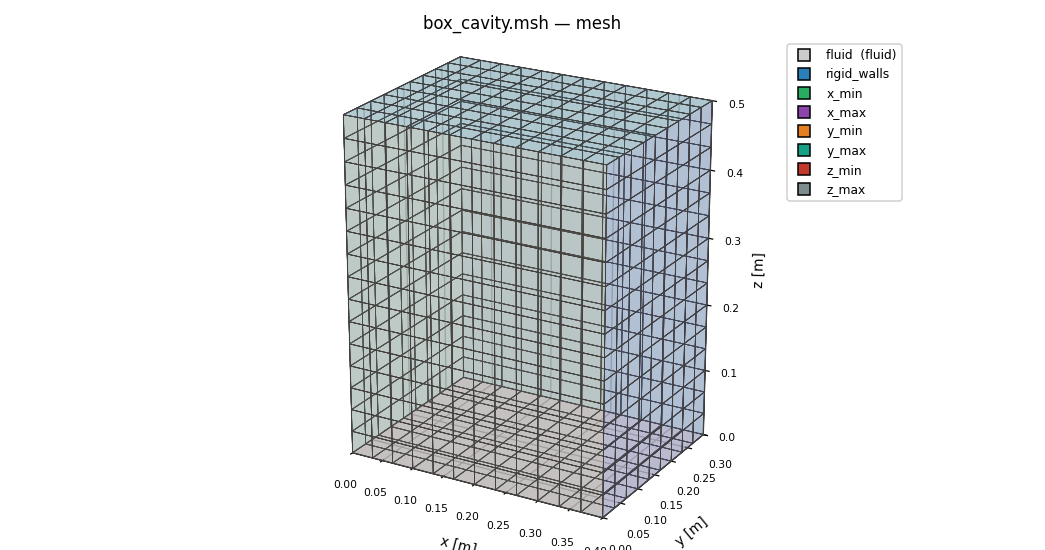

<Axes3D: title={'center': 'box_cavity.msh — mesh'}, xlabel='x [m]', ylabel='y [m]', zlabel='z [m]'>

In [2]:
geometry = MeshFile(os.path.join("..", "Library", "box_cavity.msh"))
picked = os.path.abspath(str(geometry.path))
print(type(geometry).__name__, "->", os.path.basename(picked))

# Read the file as it is, only to see what is in it. Nothing is assembled
# here: that is the next section.
nodes, elements, boundaries, groups = load_mesh_with_groups(picked, verbose=False)

# The mesh is the geometry, so the box is measured on it and nothing about
# the cavity is written in this notebook.
BOX = [np.unique(np.round(nodes[:, i], 9)) for i in range(3)]
LX, LY, LZ = (a[-1] - a[0] for a in BOX)
NX, NY, NZ = (a.size - 1 for a in BOX)
SIDES = (LX, LY, LZ)

print()
print(f"{os.path.basename(picked)}: {len(nodes)} nodes, "
      f"box {LX:.3f} x {LY:.3f} x {LZ:.3f} m, "
      f"{NX} x {NY} x {NZ} = {NX * NY * NZ} elements")
for name, group in sorted(groups.items(), key=lambda kv: -kv[1]["dim"]):
    kind = {3: "volume", 2: "surface", 1: "edge"}.get(group["dim"], "?")
    print(f"  {kind:<8} {name:<14} {len(group['nodes']):5d} nodes")

# The mesh itself, in 3D: the elements of every surface, edges and all.
plot_mesh_3d(nodes, groups, title=f"{os.path.basename(picked)} — mesh")

# The inline backend draws a picture, not a scene. To turn the mesh by hand,
# open gmsh's own viewer - it blocks this cell until the window is closed:
# open_in_gmsh(picked)


---
## 3. The model

`build_model` reads the mesh, checks it against `f_max`, draws it coloured by
role and assembles. The element size was never typed: it follows from `f_max`
and the ten elements per wavelength rule, $h = c_0/(f_{max} n_\lambda)$; for a
mesh loaded as it stands, `f_max` only says what it is checked against.


ModelSpec
  geometry     MeshFile(path=PosixPath('/Users/danielefabbri/Desktop/pycafe_new/Library/box_cavity.msh'), rename={}, drop=())
  fluid        air: rho0 = 1.204 kg/m3, c0 = 343.0 m/s
  f_max        1000.0 Hz (lambda = 343 mm)
  mesh size    34.3 mm (10 elements per wavelength)
  mesh file    /Users/danielefabbri/Desktop/pycafe_new/Library/box_cavity.msh



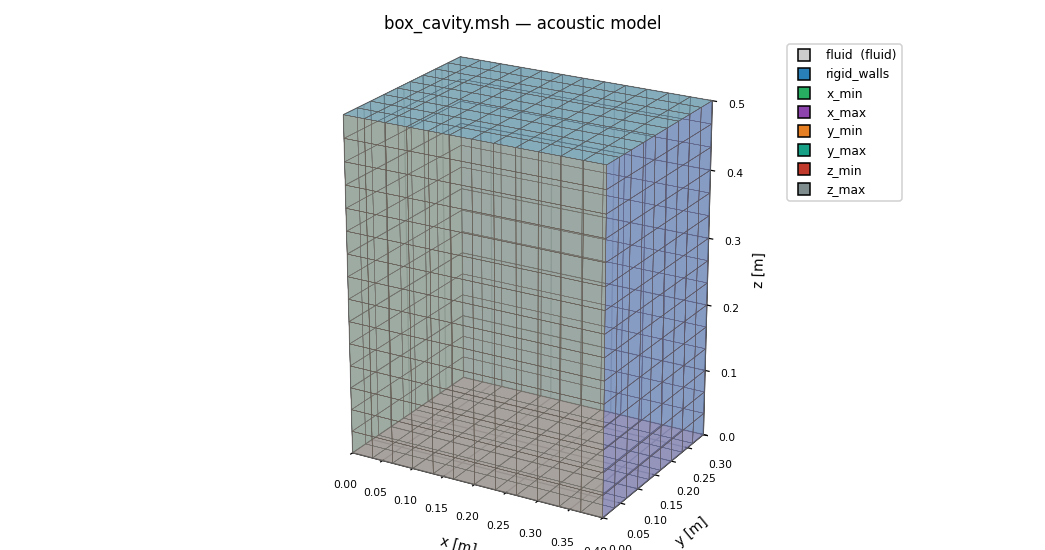

Acoustic domain from physical group 'fluid': CHEXA8


/Users/danielefabbri/Desktop/pycafe_new/Library/box_cavity.msh  (acoustic analysis)
-----------------------------------------------------------------------------------
  2080 nodes, 846 x Quadrilateral 4, 1620 x Hexahedron 8
  roles: fluid = 'fluid'
  · fluid element size: 33.3 / 33.3 / 33.3 mm (min / mean / max)
  · good to ~1% up to 792 Hz (13 elements per wavelength at c0 = 343 m/s)
  · at 1000 Hz: 10.3 elements per wavelength, dispersion error ~1.55%
  · selectable boundaries: rigid_walls, x_max, x_min, y_max, y_min, z_max, z_min
  => usable
domains in box_cavity.msh (acoustic analysis)
  fluid       group 'fluid'          <- air: rho0 = 1.204 kg/m3, c0 = 343.0 m/s
  selectable boundaries: rigid_walls, x_max, x_min, y_max, y_min, z_max, z_min

walls  : hard (dp/dn = 0 is the natural BC - no DOF is constrained)
assembled: acoustic -> ['C', 'C_op', 'C_red', 'C_red_op', 'K', 'K_red', 'M', 'M_red', 'bc', 'bc_velocity', 'boundary_dim', 'debug', 'elem_type', 'idx_free', 'p0_nodes', 'pml_

In [3]:
spec = ModelSpec(
    geometry=geometry,
    analysis=ANALYSIS,             # what to look for, and what to assemble
    fluid=FLUID,
    f_max=F_MAX,
    work_dir=".",
)
print(spec.describe())
print()

model = build_model(spec)          # read -> validate -> draw -> assemble

nodes = model["nodes"]
elements = model["elements"]
groups = model["groups"]
system = model["system"]
report = model["report"]

print(report)
print(describe_domains(report, FLUID, STRUCTURE))
print()
print("walls  : hard (dp/dn = 0 is the natural BC - no DOF is constrained)")
print("assembled:", model["analysis"], "->", sorted(system))


---
## 4. Modal analysis

$\mathbf K\mathbf p = \omega^{2}\mathbf M\mathbf p$, nothing constrained.
`solve_modal_acoustic_reduced` returns the frequencies in hertz and the shapes
as one nodal pressure per column, ascending. The uniform pressure mode at
$f = 0$ is a genuine solution of the hard-walled cavity and the solver drops it, so
the first column back is the first real mode.


In [4]:
K, M = system["K"], system["M"]
freqs, modes = solve_modal_acoustic_reduced(K, M, num_modes=N_MODES)

print(f"{modes.shape[0]} pressure DOFs, {modes.shape[1]} modes")
print()
for i, f in enumerate(freqs):
    print(f"  mode {i+1:2d}   {f:8.2f} Hz")

2080 pressure DOFs, 12 modes

  mode  1     343.63 Hz
  mode  2     429.98 Hz
  mode  3     550.42 Hz
  mode  4     574.57 Hz
  mode  5     669.49 Hz
  mode  6     691.03 Hz
  mode  7     717.64 Hz
  mode  8     795.67 Hz
  mode  9     813.88 Hz
  mode 10     867.33 Hz
  mode 11     898.69 Hz
  mode 12     932.92 Hz


`plot_pressure_3d` colours the outer faces of the mesh by the field. Rigid
walls put a pressure antinode on every boundary, so the six faces carry the
whole pattern: one nodal plane (white) per half wave along that direction.
Each mode is normalised on its own peak and its sign fixed positive, since an
eigenvector is defined up to a factor.


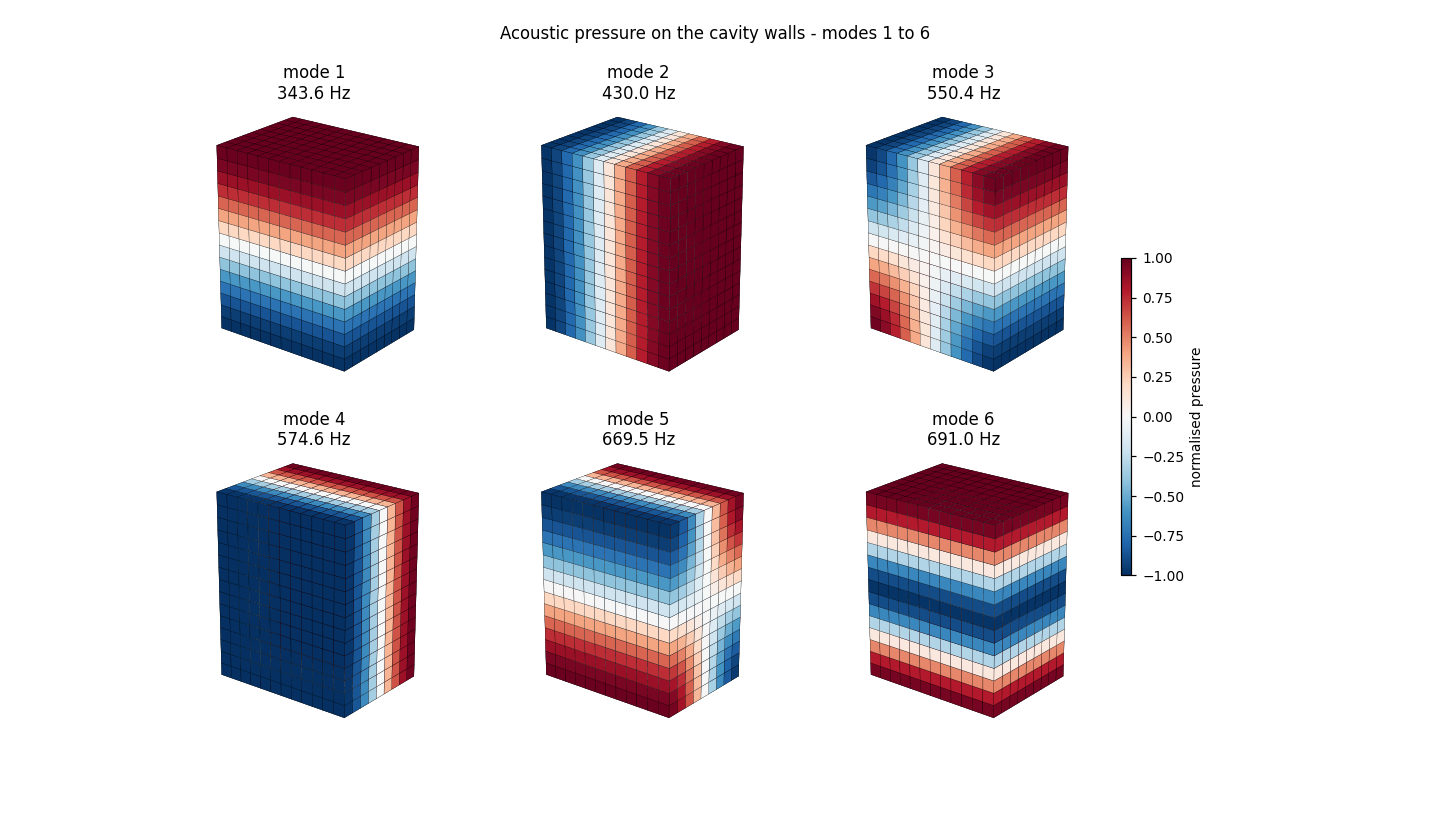

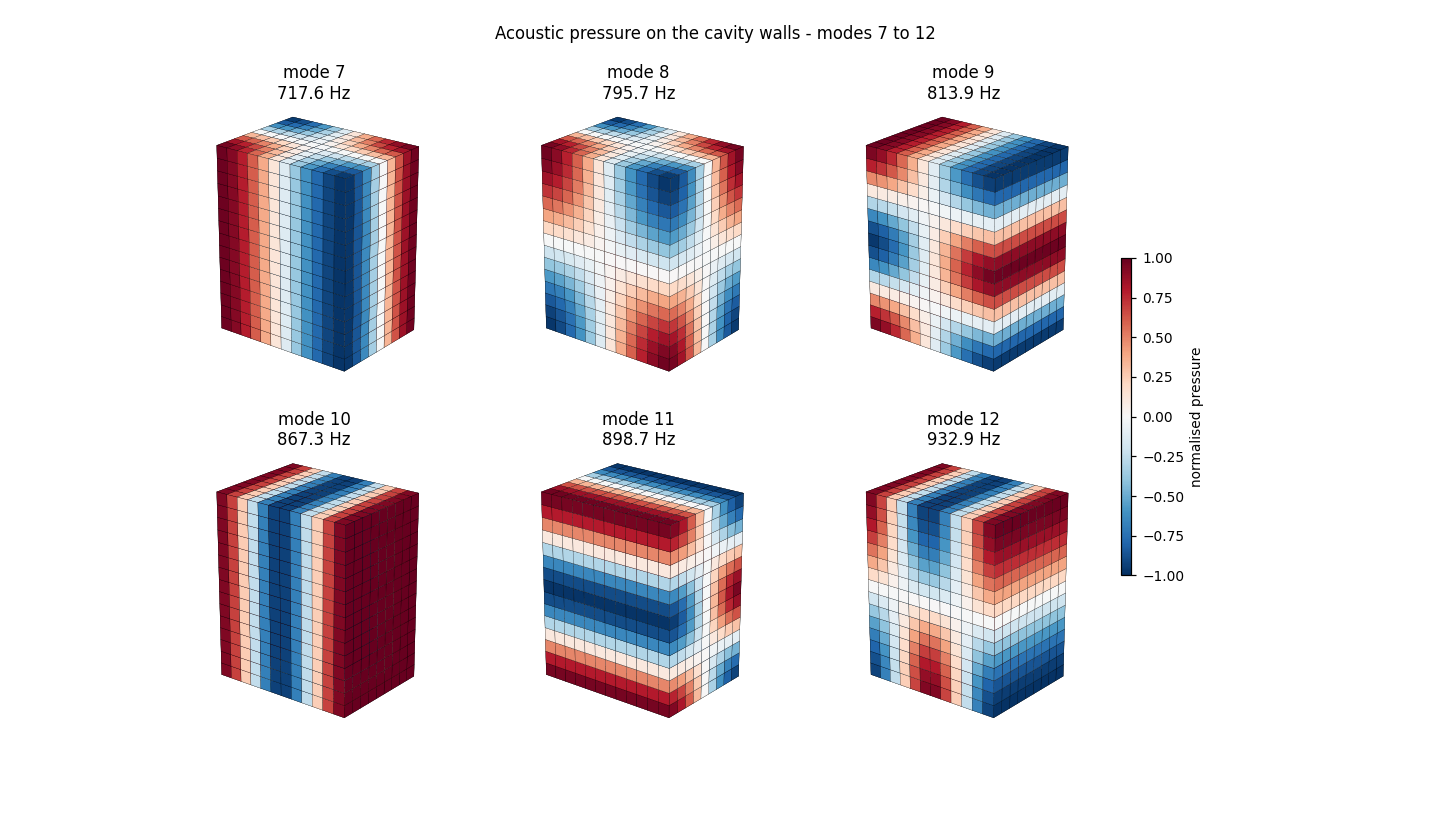

In [5]:
for first in (0, 6):
    fig = plt.figure(figsize=(13, 7.5))
    for k, i in enumerate(range(first, min(first + 6, N_MODES))):
        # An eigenvector is defined up to a factor: normalise each mode on
        # its own peak and make that peak positive, or the same mode comes
        # out red or blue at random.
        p_mode = modes[:, i] / np.abs(modes[:, i]).max()
        if p_mode[np.abs(p_mode).argmax()] < 0:
            p_mode = -p_mode

        ax = fig.add_subplot(2, 3, k + 1, projection="3d")
        plot_pressure_3d(nodes, elements, p_mode, part="real", cmap="RdBu_r",
                         clim=(-1, 1), ax=ax, colorbar=False, show=False,
                         elev=22, azim=-52,
                         title=f"mode {i + 1}\n{freqs[i]:.1f} Hz")
        # The box is 0.40 x 0.30 x 0.50 m in every panel and says so once, in
        # the mesh above: here the axes are only in the way of the pattern.
        ax.set_axis_off()

    fig.suptitle("Acoustic pressure on the cavity walls - modes "
                 f"{first + 1} to {min(first + 6, N_MODES)}", y=0.97)
    fig.colorbar(cm.ScalarMappable(norm=plt.Normalize(-1, 1), cmap="RdBu_r"),
                 ax=fig.axes, shrink=0.5, aspect=30, pad=0.02,
                 label="normalised pressure")
    plt.show()


---
### 4.2 Against the closed form

Every computed mode keeps the analytical shape it correlates best with,

$$ \mathrm{MAC}(\mathbf{a}, \mathbf{p}) =
   \frac{(\mathbf{a}^{T}\mathbf{p})^{2}}
        {(\mathbf{a}^{T}\mathbf{a})(\mathbf{p}^{T}\mathbf{p})}
   \in [0, 1] $$

and that $(l,m,n)$ gives the frequency it should have had. Pairing by shape and
not by order matters: two analytical frequencies can sit a few hertz apart, and
reading the labels off the sorted list would swap them.


In [6]:
# Pairing by shape, and the frequency each label says the mode should have
# had: identify_cavity_modes measures the MAC of every computed mode against
# every cos(l pi x/Lx) cos(m pi y/Ly) cos(n pi z/Lz) up to order-1 half waves,
# written about the corner the mesh turned out to have.
paired = identify_cavity_modes(nodes, modes, freqs, C0, SIDES, order=5)

labels, exact, error = paired["labels"], paired["exact"], paired["error"]

print(f"{'mode':>5s} {'(l,m,n)':>10s} {'analytical [Hz]':>17s}"
      f" {'pyCAFE [Hz]':>13s} {'error [%]':>11s}")
for i in range(N_MODES):
    print(f"{i+1:5d} {str(labels[i]):>10s} {exact[i]:17.2f}"
          f" {freqs[i]:13.2f} {error[i]:11.3f}")
print(f"\nmean error {np.abs(error).mean():.3f} % - "
      f"max error {np.abs(error).max():.3f} %")


 mode    (l,m,n)   analytical [Hz]   pyCAFE [Hz]   error [%]
    1  (0, 0, 1)            343.00        343.63       0.183
    2  (1, 0, 0)            428.75        429.98       0.286
    3  (1, 0, 1)            549.07        550.42       0.246
    4  (0, 1, 0)            571.67        574.57       0.508
    5  (0, 1, 1)            666.67        669.49       0.422
    6  (0, 0, 2)            686.00        691.03       0.733
    7  (1, 1, 0)            714.58        717.64       0.428
    8  (1, 1, 1)            792.64        795.67       0.382
    9  (1, 0, 2)            808.96        813.88       0.607
   10  (2, 0, 0)            857.50        867.33       1.146
   11  (0, 1, 2)            892.97        898.69       0.641
   12  (2, 0, 1)            923.56        932.92       1.014

mean error 0.550 % - max error 1.146 %


A diagonal of ones is what the pairing was chosen to produce. What the whole
matrix adds is everything off it: near zero there, and each computed mode
resembles its own label and no other.


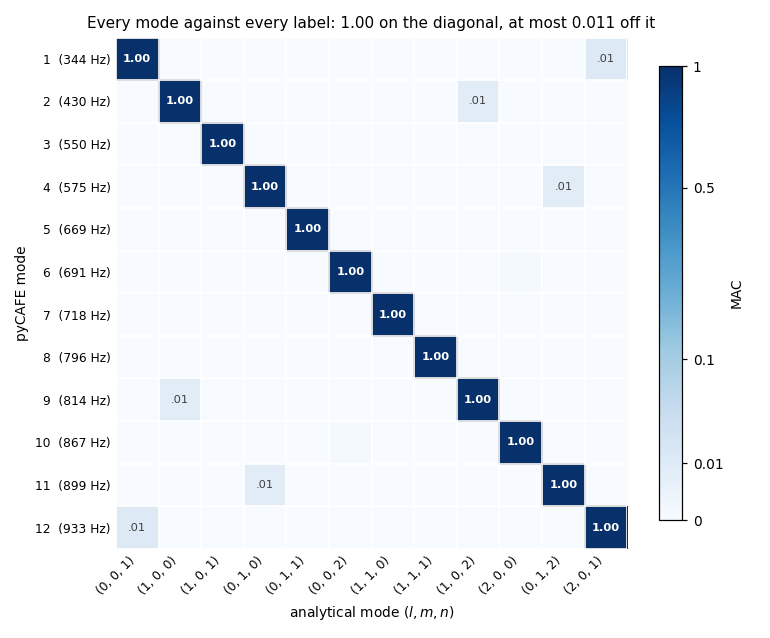

smallest MAC on the diagonal  1.0000
largest MAC off the diagonal  0.0110


In [7]:
MAC = paired["mac"]
off_diagonal = MAC - np.diag(np.diag(MAC))

plot_mac_matrix(MAC, labels, freqs, show=True)

print(f"smallest MAC on the diagonal  {np.diag(MAC).min():.4f}")
print(f"largest MAC off the diagonal  {off_diagonal.max():.4f}")


---
## Summary

`Library/box_cavity.msh`, 0.40 × 0.30 × 0.50 m, 12 × 9 × 15 `CHEXA8`, 2080
pressure DOFs: every shape matches its $(l,m,n)$ to a MAC of 1.00 against at
most 0.01 with any other, with a **mean frequency error of 0.55 %** and a
**maximum of 1.1 %** on mode 10, $(2,0,0)$.

The error is the numerical dispersion of a trilinear element and always
positive: the discretised cavity is stiffer than the continuum. It scales with
the square of the mesh size, so rebuilding the case at twice the `f_max`
(`Library/make_library.py`) divides it by four.
